In [2]:
import pandas as pd
import humanize as hu

In [4]:
file = pd.read_csv("Global Health Statistics.csv")

In [6]:
file = file.dropna() 
file = file.reset_index(drop=True)

In [8]:
updated = file.head(1000)
file = updated

In [10]:
Unique_Disease = file['Disease Name'].unique()
Unique_Disease

array(['Malaria', 'Ebola', 'COVID-19', "Parkinson's Disease",
       'Tuberculosis', 'Dengue', 'Rabies', 'Cholera', 'Leprosy', 'Cancer',
       'Diabetes', 'Measles', 'Zika', "Alzheimer's Disease", 'Polio',
       'Hypertension', 'Asthma', 'HIV/AIDS', 'Influenza', 'Hepatitis'],
      dtype=object)

In [12]:
import matplotlib.pyplot as plt

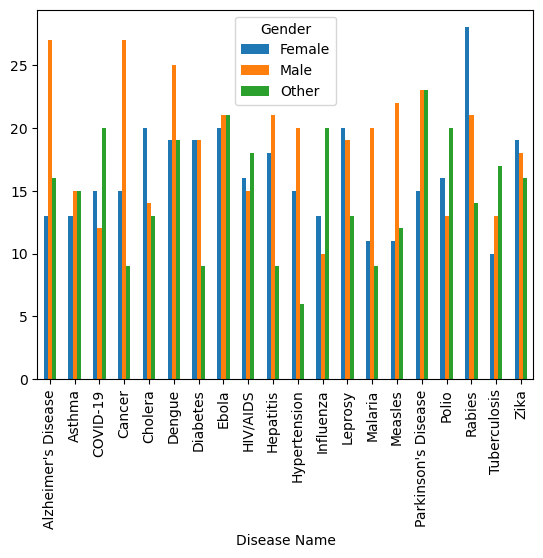

In [14]:
new = pd.crosstab(file['Disease Name'], file['Gender']).plot(kind='bar')
plt.show()

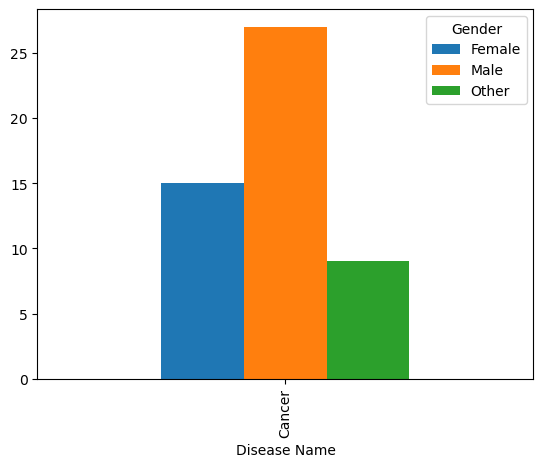

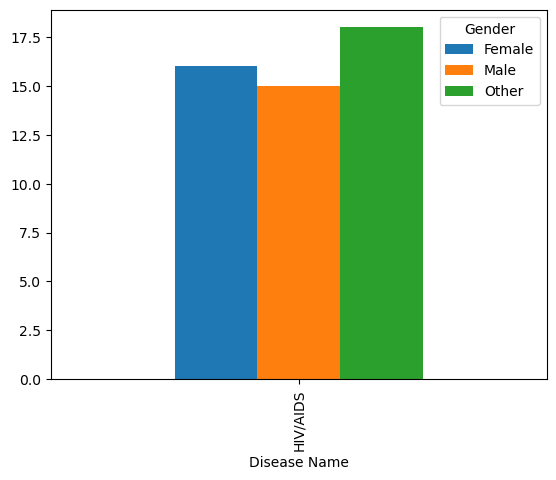

In [16]:
onlycancer = file[file['Disease Name'] == 'Cancer']
onlyHIV = file[file['Disease Name'] == 'HIV/AIDS']

an = pd.crosstab(onlycancer['Disease Name'], file['Gender']).plot(kind='bar')
plt.show()

an = pd.crosstab(onlyHIV['Disease Name'], file['Gender']).plot(kind='bar')
plt.show()

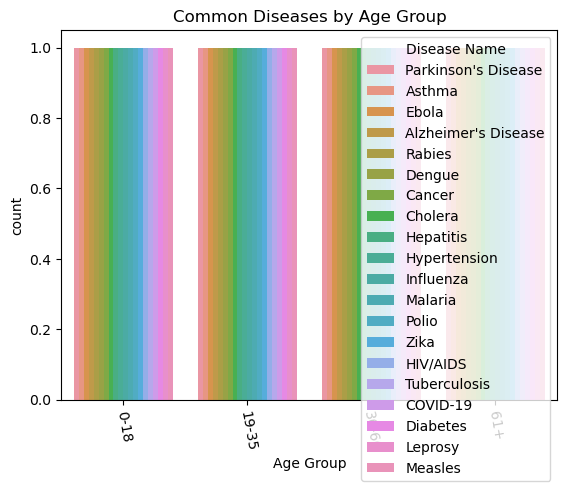

In [18]:
grouped_data = file.groupby(['Age Group', 'Disease Name']).size().reset_index(name='Count')
common_diseases = grouped_data.sort_values(by=['Age Group', 'Count'], ascending=[True, False])

import seaborn as sns
#plt.figure(figsize=(15, 15))  
sns.countplot(common_diseases, x='Age Group', hue='Disease Name')
plt.title('Common Diseases by Age Group')
plt.xticks(rotation=10000)
plt.show()

<Figure size 1200x600 with 0 Axes>

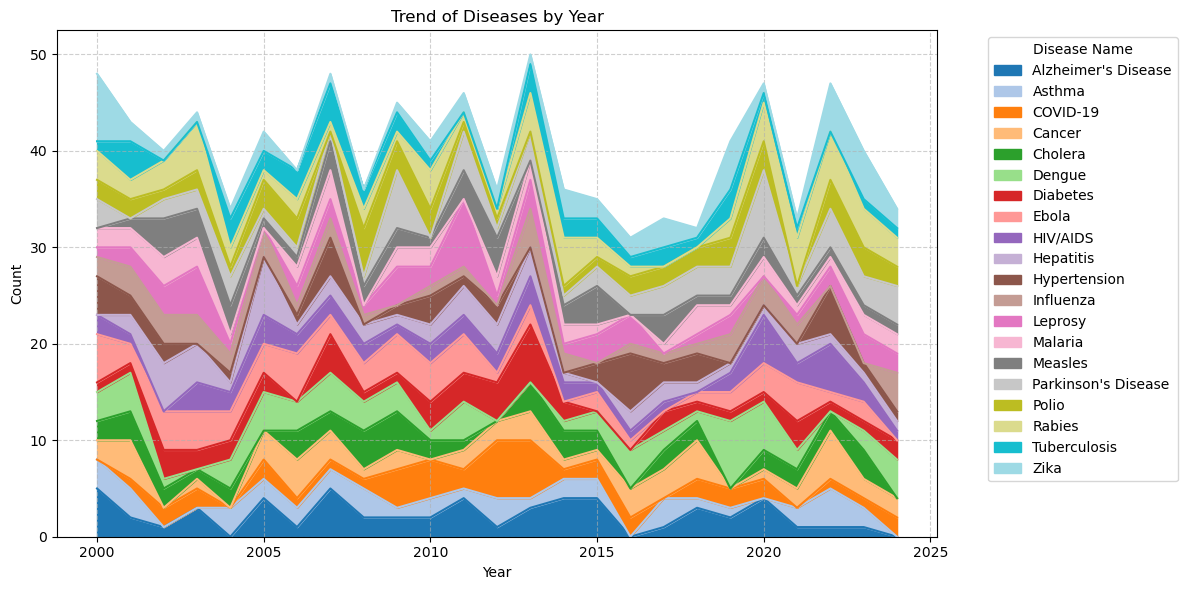

In [20]:
yearly_disease_data = file.groupby(['Year', 'Disease Name']).size().reset_index(name='Count')
pivot_data = yearly_disease_data.pivot(index='Year', columns='Disease Name', values='Count').fillna(0)
plt.figure(figsize=(12, 6))  # Set figure size
pivot_data.plot(kind='area', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Trend of Diseases by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Disease Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [22]:
data = file[["Year", "Disease Name"]]

In [24]:
print(data)

     Year         Disease Name
0    2013              Malaria
1    2002                Ebola
2    2015             COVID-19
3    2011  Parkinson's Disease
4    2013         Tuberculosis
..    ...                  ...
995  2008                Polio
996  2012         Hypertension
997  2001               Asthma
998  2022              Cholera
999  2012         Hypertension

[1000 rows x 2 columns]


In [26]:
data = data.drop_duplicates().reset_index(drop=True)
print(data)

     Year         Disease Name
0    2013              Malaria
1    2002                Ebola
2    2015             COVID-19
3    2011  Parkinson's Disease
4    2013         Tuberculosis
..    ...                  ...
423  2010               Dengue
424  2016               Rabies
425  2023  Alzheimer's Disease
426  2022            Hepatitis
427  2012         Hypertension

[428 rows x 2 columns]


<Axes: xlabel='Year', ylabel='Disease Name'>

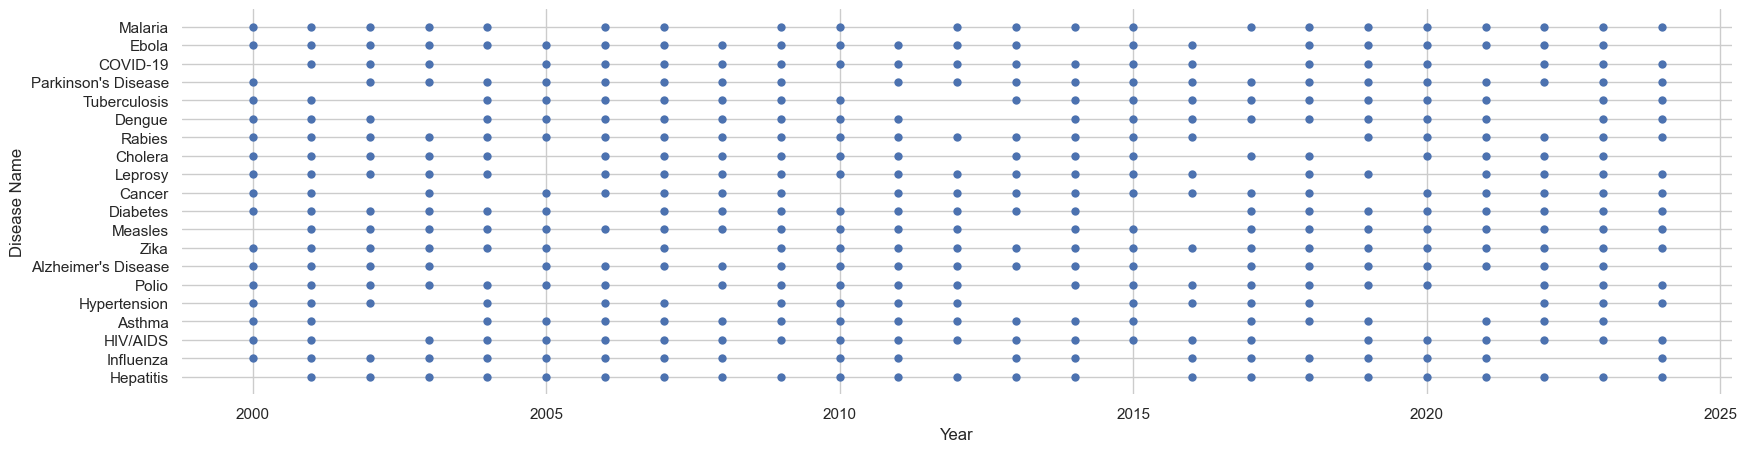

In [28]:
sns.set_theme(style="whitegrid")


f, ax = plt.subplots(figsize=(20, 5))
sns.despine(f, left=True, bottom=True)
clarity_ranking = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
sns.scatterplot(x="Year", y="Disease Name",
                hue_order=clarity_ranking,
                sizes=(1, 8), linewidth=0,
                data=data, ax=ax)

In [30]:
data2 = file[['Year','Disease Name', 'Availability of Vaccines/Treatment']]

In [32]:
data2 = data2.head(1000)
print(data2)

     Year         Disease Name Availability of Vaccines/Treatment
0    2013              Malaria                                 No
1    2002                Ebola                                Yes
2    2015             COVID-19                                Yes
3    2011  Parkinson's Disease                                Yes
4    2013         Tuberculosis                                Yes
..    ...                  ...                                ...
995  2008                Polio                                 No
996  2012         Hypertension                                 No
997  2001               Asthma                                Yes
998  2022              Cholera                                 No
999  2012         Hypertension                                Yes

[1000 rows x 3 columns]


In [34]:
data2 = data2.drop_duplicates().reset_index(drop=True)

In [36]:
print(data2)

     Year         Disease Name Availability of Vaccines/Treatment
0    2013              Malaria                                 No
1    2002                Ebola                                Yes
2    2015             COVID-19                                Yes
3    2011  Parkinson's Disease                                Yes
4    2013         Tuberculosis                                Yes
..    ...                  ...                                ...
636  2009              Measles                                 No
637  2005  Alzheimer's Disease                                Yes
638  2012         Hypertension                                 No
639  2022              Cholera                                 No
640  2012         Hypertension                                Yes

[641 rows x 3 columns]


In [38]:
data2 = data2.sort_values(by='Year', ascending=True)
print(data2.head())

     Year         Disease Name Availability of Vaccines/Treatment
433  2000             HIV/AIDS                                 No
23   2000               Asthma                                 No
559  2000            Influenza                                 No
622  2000              Cholera                                Yes
303  2000  Parkinson's Disease                                 No


In [40]:
twothousand = data2[data2['Year'] == 2000]
print(twothousand)

     Year         Disease Name Availability of Vaccines/Treatment
433  2000             HIV/AIDS                                 No
23   2000               Asthma                                 No
559  2000            Influenza                                 No
622  2000              Cholera                                Yes
303  2000  Parkinson's Disease                                 No
125  2000                 Zika                                Yes
239  2000                 Zika                                 No
411  2000         Hypertension                                Yes
174  2000            Influenza                                Yes
598  2000              Malaria                                 No
595  2000              Malaria                                Yes
266  2000               Cancer                                 No
143  2000                Ebola                                 No
264  2000               Asthma                                Yes
63   2000 

In [42]:
twothousand = twothousand.reset_index(drop=True)

In [44]:
print(twothousand)

    Year         Disease Name Availability of Vaccines/Treatment
0   2000             HIV/AIDS                                 No
1   2000               Asthma                                 No
2   2000            Influenza                                 No
3   2000              Cholera                                Yes
4   2000  Parkinson's Disease                                 No
5   2000                 Zika                                Yes
6   2000                 Zika                                 No
7   2000         Hypertension                                Yes
8   2000            Influenza                                Yes
9   2000              Malaria                                 No
10  2000              Malaria                                Yes
11  2000               Cancer                                 No
12  2000                Ebola                                 No
13  2000               Asthma                                Yes
14  2000  Alzheimer's Dis